# Diabetes Hospital Readmission - Predictive Modeling

## Overview
Transitioning from the SQL EDA phase, this notebook will use statistical methods and machine learning to predict early readmission among diabetic patients.

## Problem Statement
In this dataset, 11% of diabetic patients face early readmission within 30 days of discharge. These early returns represent a financial burden for hospitals and also indicate that something went wrong - whether in treatment, discharge planning, or general patient care.
Identifying which patients are most likely to return before they're discharged allows hospitals to find ways to intervene and reduce preventable visits.
 
 

## Purpose
To develop a risk flagging system that identifies diabetic patients with high-risk profiles of early readmission using clinical data available to enhance patient care in US hospitals.

## Approach
1. Data loading and preprocessing
2. Feature Engineering
3. Statistical testing
4. Logistic Regression model
5. Random Forest model
6. SHAP feature importance
7. Flagging system

## Tools
- Databricks
- Pandas
- Scikit-learn
- SHAP 

In [0]:
import pandas as pd
import numpy as np

encounters = spark.sql("SELECT * FROM diabetesdb.diabetes_data").toPandas()

print(f"Shape: {encounters.shape}")
print(f"Columns: {encounters.columns}")
print(f"Readmission count:", encounters['readmitted'].value_counts())
print(f"Missing Values: {encounters.isnull().sum().sum()}")

Shape: (101766, 50)
Columns: Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')
Readmission count: readmitted
NO     548

## 1. Preprocessing
Prepare data for modeling

In [0]:
# ? we saw in SQL must be dealt with
encounters = encounters.replace('?', np.nan)

missing = encounters.isnull().sum()
print(missing)

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum                   0
A1Cresult                       0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [0]:
# Drop columns not of interest
encounters = encounters.drop(columns=['weight', 'payer_code', 'medical_specialty']  , errors='ignore')

# Drop rows with nulls
encounters = encounters.dropna(subset=['race','diag_1','diag_2','diag_3'])

print(f"Shape: {encounters.shape}")

Shape: (98053, 47)


## 2. Feature Engineering
Establish a target variable for modeling

In [0]:
# binary target — 1 if readmitted within 30 days, 0 otherwise
encounters['early_readmission'] = (encounters['readmitted'] == '<30').astype(int)

print(f"Early readmission rate: {encounters['early_readmission'].mean():.2%}")
print(f"\nClass distribution:\n{encounters['early_readmission'].value_counts()}")

Early readmission rate: 11.29%

Class distribution:
early_readmission
0    86987
1    11066
Name: count, dtype: int64


In [0]:
# Age mapping
age_mapping = {
    '[0-10)': 0,
    '[10-20)': 1,
    '[20-30)': 2,
    '[30-40)': 3,
    '[40-50)': 4,
    '[50-60)': 5,
    '[60-70)': 6,
    '[70-80)': 7,
    '[80-90)': 8,
    '[90-100)': 9
}
encounters['age'] = encounters['age'].map(age_mapping)
# Insulin mapping
insulin_mapping = {
    'No': 0,
    'Steady': 1,
    'Up': 2,
    'Down': 3
}
encounters['insulin'] = encounters['insulin'].map(insulin_mapping)

encounters['gender'] = (encounters['gender'] == 'Male').astype(int)

encounters = pd.get_dummies(encounters, columns=['race','change','diabetesMed'], drop_first=True, dtype=int)


print(f"Shape: {encounters.shape}")
print(encounters.head())

Shape: (98053, 51)
   encounter_id  patient_nbr  gender  ...  race_Other  change_No  diabetesMed_Yes
1        149190     55629189       0  ...           0          0                1
2         64410     86047875       0  ...           0          1                1
3        500364     82442376       1  ...           0          0                1
4         16680     42519267       1  ...           0          0                1
5         35754     82637451       1  ...           0          1                1

[5 rows x 51 columns]


In [0]:
# features based on SQL exploration findings
features = [
    'age',
    'gender',
    'insulin',
    'num_medications',
    'number_diagnoses',
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'number_inpatient',
    'number_emergency',
    'number_outpatient',
    'race_Caucasian',
    'race_Hispanic',
    'race_Asian',
    'race_Other',
    'change_No',
    'diabetesMed_Yes'
]

X = encounters[features]
y = encounters['early_readmission']

print(f"Features: {X.shape[1]}")
print(f"Target distribution:\n{y.value_counts()}")

Features: 17
Target distribution:
early_readmission
0    86987
1    11066
Name: count, dtype: int64


## 3. Statistical Testing
Are the key features statistically significant predictors of early readmission at the significance level of .05.

Tests:

**Chi-Square** is used to test whether age, gender, insulin, etc. (categorical variables) are independent or related.

**Point Biserial Correlation** is used to measure num_medications, number_diagnoses, time_in_hospital, etc. (continuous variables) and tests whether they're correlated with early readmission or not.



In [0]:
from scipy.stats import chi2_contingency, pointbiserialr

# Chi-square tests for categorical variables
categorical = ['age', 'gender', 'insulin', 'change_No', 'diabetesMed_Yes']

print("Chi-Square Tests:")
print("-" * 50)
for col in categorical:
    contingency = pd.crosstab(encounters[col], encounters['early_readmission'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    significance = "Significant" if p < 0.05 else "Not significant"
    print(f"{col:<20} p-value: {p:.6f}  {significance}")

# Point biserial for continuous variables
print("\nPoint Biserial Correlation:")
print("-" * 50)
continuous = ['num_medications', 'number_diagnoses', 'time_in_hospital', 
              'num_lab_procedures', 'number_inpatient', 'number_emergency']

for col in continuous:
    corr, p = pointbiserialr(encounters[col], encounters['early_readmission'])
    significance = "Significant" if p < 0.05 else "Not significant"
    print(f"{col:<25} corr: {corr:.6f}  p-value: {p:.6f}  {significance}")

Chi-Square Tests:
--------------------------------------------------
age                  p-value: 0.000000  Significant
gender               p-value: 0.432172  Not significant
insulin              p-value: 0.000000  Significant
change_No            p-value: 0.000000  Significant
diabetesMed_Yes      p-value: 0.000000  Significant

Point Biserial Correlation:
--------------------------------------------------
num_medications           corr: 0.037771  p-value: 0.000000  Significant
number_diagnoses          corr: 0.046497  p-value: 0.000000  Significant
time_in_hospital          corr: 0.043402  p-value: 0.000000  Significant
num_lab_procedures        corr: 0.019908  p-value: 0.000000  Significant
number_inpatient          corr: 0.163812  p-value: 0.000000  Significant
number_emergency          corr: 0.060558  p-value: 0.000000  Significant


### Observations
- Gender is not a statistically significant predictor and will be excluded from future modeling
- All other features show statistical significance
- All continuous features are statistically significant; however, the small correlation values suggest that a multivariate approach could be more impactful in predicting early readmission.

In [0]:
features = [
    'age',
    'insulin',
    'num_medications',
    'number_diagnoses',
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'number_inpatient',
    'number_emergency',
    'number_outpatient',
    'race_Caucasian',
    'race_Hispanic',
    'race_Asian',
    'race_Other',
    'change_No',
    'diabetesMed_Yes'
]

X = encounters[features]
y = encounters['early_readmission']


## 4. Modeling
Logistic regression model is deployed to predict early readmission and a class_weight was used to take into account of the imbalance seen in the exploratory phase.

In [0]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=25, stratify=y)

# Train
lr_mod = LogisticRegression(class_weight = 'balanced', max_iter=1000, random_state=25)
lr_mod.fit(X_train, y_train)

y_pred = lr_mod.predict(X_test)
y_prob = lr_mod.predict_proba(X_test)[:,1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(f"AUC: {roc_auc_score(y_test, y_prob):.2%}")

print(classification_report(y_test, y_pred))



Accuracy: 67.09%
AUC: 63.51%
              precision    recall  f1-score   support

           0       0.91      0.69      0.79     17398
           1       0.17      0.49      0.25      2213

    accuracy                           0.67     19611
   macro avg       0.54      0.59      0.52     19611
weighted avg       0.83      0.67      0.73     19611



### Observations
Logistic Regression baseline achieves 63.5% AUC — above random (50%) but limited.
Recall of 49% for early readmission means the model catches roughly half of 
high-risk patients.

A more complex model is needed to improve predictive performance.

## Step 5: Random Forest Model
Improving on the Logistic Regression baseline with a Random Forest classifier.
Random Forest handles non-linear relationships and feature interactions 
that Logistic Regression cannot capture

In [0]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [10, 50, 100],
    'n_estimators': [100, 200]
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=25, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best AUC: {grid_search.best_score_:.4f}")

com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$5(SequenceExecutionState.scala:139)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:139)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:136)
	at scala.collection.immutable.Range.foreach(Range.scala:192)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:136)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:724)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:442)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:442)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.can

In [0]:
from sklearn.ensemble import RandomForestClassifier

rf_mod = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=10,
    min_samples_leaf=50,
    random_state=25,
    n_jobs=-1
)

rf_mod.fit(X_train, y_train)

y_pred_rf = rf_mod.predict(X_test)
y_prob_rf = rf_mod.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2%}")
print(f"AUC: {roc_auc_score(y_test, y_prob_rf):.2%}")
print(classification_report(y_test, y_pred_rf))

Accuracy: 66.12%
AUC: 64.50%
              precision    recall  f1-score   support

           0       0.92      0.68      0.78     17398
           1       0.17      0.52      0.26      2213

    accuracy                           0.66     19611
   macro avg       0.54      0.60      0.52     19611
weighted avg       0.83      0.66      0.72     19611



### Observations
GridSearchCV identified optimal parameters (max_depth=10, min_samples_leaf=50, 
n_estimators=200) with a data-driven tuning approach. The tuned Random Forest marginally improves AUC 
(64.50% vs 63.51%) over Logistic Regression but both models face a performance ceiling. 
This is consistent with the weak individual correlations found in 
statistical testing — no single feature strongly predicts readmission alone.

## 6. SHAP Feature Importance
Shows the contribution of each feature to the model predictions

In [0]:
%pip install shap

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:141)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:136)
	at scala.collection.immutable.Range.foreach(Range.scala:192)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:136)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:724)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:442)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:442)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:495)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:725)
	at com.data

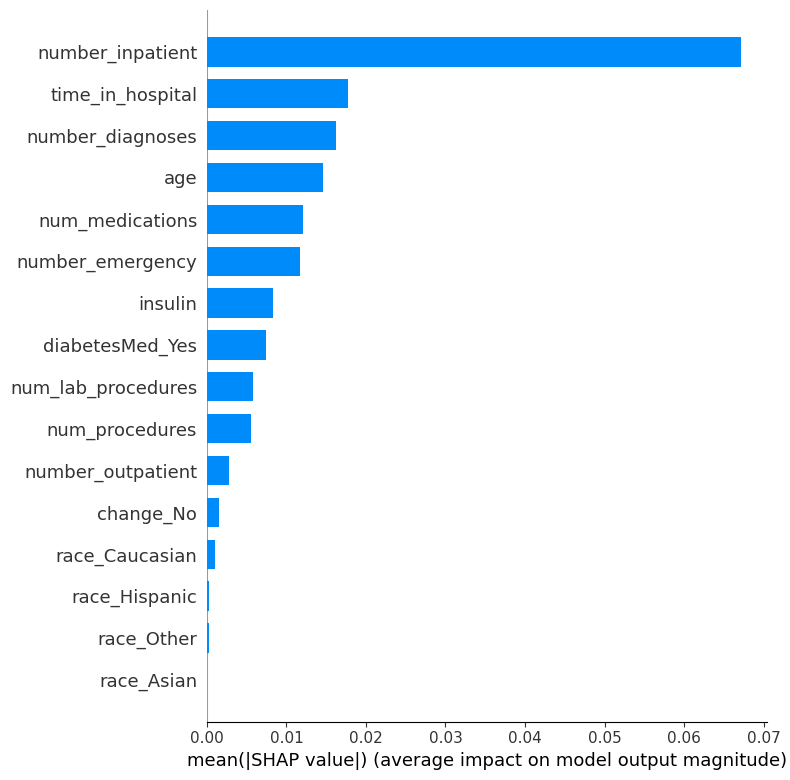

In [0]:
import shap


explainer = shap.TreeExplainer(rf_mod)

X_sample = X_test.sample(1000, random_state=25)
shap_values = explainer.shap_values(X_sample)

# Summary plot
shap.summary_plot(shap_values[:, :, 1], X_sample, plot_type="bar")

### Observations
SHAP analysis shows that the prior inpatient visit remains as the most influential predictor of early readmission, with time_in_hospital and number_diagnoses following, consistent with the SQL EDA phase findings. 

Race features are not a meaningful driver in determining early readmission, validating the SQL findings.

## 7. Risk Flagging System
Translating the model evaluation into clinical action by developing a system in which a high-risk case would get flagged, allowing for proper intervention.

A lower value threshold of 0.40 is used instead of 0.50, with the logic of missing a high-risk case being a lot costlier than a false alarm.

In [0]:
# dataframe of the testing features
results = X_test.copy()
results['actual_readmission'] = y_test.values
results['risk_score'] = y_prob_rf
# Convert False/True to 0/1
results['flagged_high_risk'] = (y_prob_rf >= 0.40).astype(int)


flagged = results[results['flagged_high_risk'] == 1]
not_flagged = results[results['flagged_high_risk'] == 0]

total_actual = results['actual_readmission'].sum()
caught = flagged['actual_readmission'].sum()
missed = not_flagged['actual_readmission'].sum()

print(f"Total actual early readmissions: {total_actual}")
print(f"Caught by flagging system: {caught} ({caught/total_actual:.1%})")
print(f"Missed by flagging system: {missed} ({missed/total_actual:.1%})")
print(f"\nTotal patients flagged: {len(flagged)}")
print(f"Of flagged patients, actual readmissions: {caught} ({caught/len(flagged):.1%})")

Total actual early readmissions: 2213
Caught by flagging system: 1889 (85.4%)
Missed by flagging system: 324 (14.6%)

Total patients flagged: 14239
Of flagged patients, actual readmissions: 1889 (13.3%)


In [0]:
# Evaluate model performance on non-young-adult patients
results_older = results[encounters.loc[X_test.index, 'age'] != 2]

total_actual_older = results_older['actual_readmission'].sum()
flagged_older = results_older[results_older['flagged_high_risk'] == 1]
not_flagged_older = results_older[results_older['flagged_high_risk'] == 0]

caught_older = flagged_older['actual_readmission'].sum()
missed_older = not_flagged_older['actual_readmission'].sum()

print(f"Actual early readmissions (excl. age 20-30): {total_actual_older}")
print(f"Caught: {caught_older} ({caught_older/total_actual_older:.1%})")
print(f"Missed: {missed_older} ({missed_older/total_actual_older:.1%})")
print(f"\nPatients flagged: {len(flagged_older)}")
print(f"Of those flagged, true readmissions: {caught_older} ({caught_older/len(flagged_older):.1%})")

Actual early readmissions (excl. age 20-30): 2168
Caught: 1849 (85.3%)
Missed: 319 (14.7%)

Patients flagged: 14094
Of those flagged, true readmissions: 1849 (13.1%)


### Observations
The threshold at .40 catches ~85% of the actual readmissions; however, it produced low precision meaning that the system would flag many patients who would not have been readmitted. 
The system was rerun, excluding the unexplained young adult group; however, it essentially produced an identical outcome as the first run. 

This is the consequence of the model's 64% AUC ceiling and not having the best ability to differentiate between a high-risk case or not.


## Conclusion
Returning to the problem statement - can a flagging system identify patients at high-risk of early readmission using the clinical data at hand?

The system identifies clear clinical features that are shown across high-risk profiles, supported by statistical tests and a SHAP feature importance visual. However, the model achieved a ceiling AUC 64%, suggesting that the model cannot consistently distinguish between high-risk and low-risk cases; thus, the current flagging system is not reliable enough to be deployed.

The data currently collected during an encounter is insufficient for a reliable early readmission prediction. Further factors, such as, Medication compliance and post-discharge data, could be beneficial to establish a stronger flagging system. 

**Strongest Finding** remains that older patients with multiple prior inpatient visits are the highest risk group and that hospitals should prioritize further on discharge planning.